导出

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from mpl_toolkits.mplot3d import Axes3D

Solution at t = 0.0, 0.5, 1.0

Transverse displacement ω(x,t):
t = 0.0: min = 0.000000, max = 1.570796
t = 0.5: min = 0.000000, max = 1.378535
t = 1.0: min = 0.000000, max = 0.848823

Cross-sectional rotation θ(x,t):
t = 0.0: min = -0.330673, max = 0.330673
t = 0.5: min = -0.290217, max = 0.290217
t = 1.0: min = -0.178969, max = 0.178969


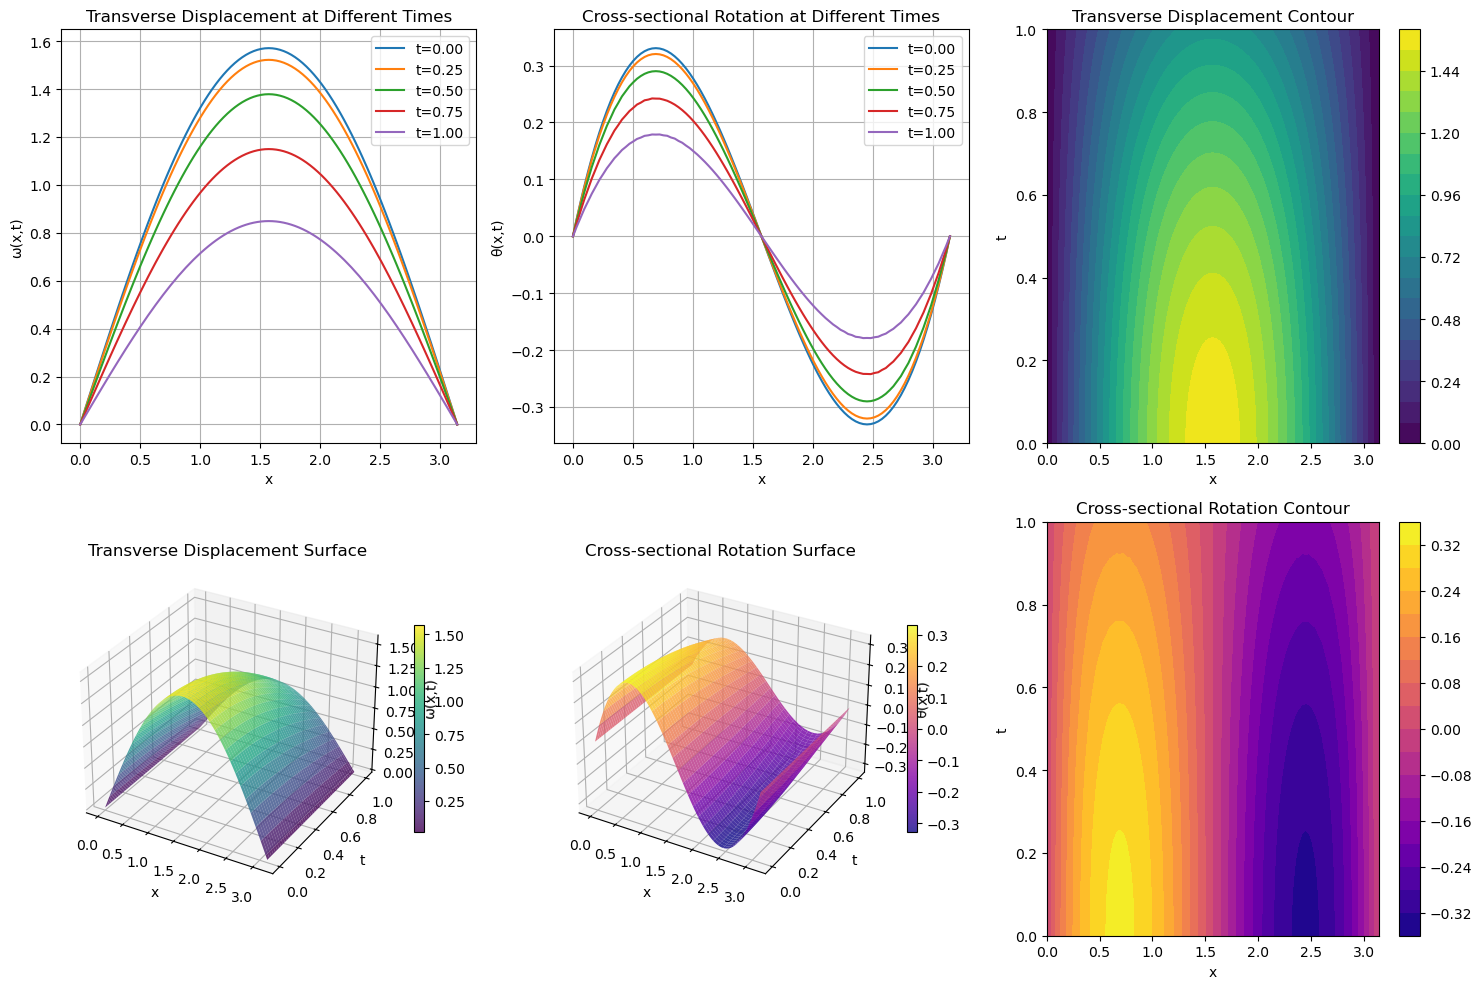


Solution completed successfully!
Grid size: 101 spatial points × 1001 temporal points
dx = 0.031416, dt = 0.001000
✅ Readable CSV files exported to: results_claude_csv


In [4]:
# ===============================
# Domain parameters
# ===============================
L = np.pi
T = 1.0

nx = 101
nt = 1001

dx = L / (nx - 1)
dt = T / (nt - 1)

x = np.linspace(0, L, nx)
t = np.linspace(0, T, nt)

omega = np.zeros((nt, nx))
theta = np.zeros((nt, nx))


def g(x, t):
    return np.cos(t) - (np.pi / 2) * np.sin(x) * np.cos(t)


omega[0, :] = (np.pi / 2) * np.sin(x)
theta[0, :] = (np.pi / 2) * np.cos(x) + (x - np.pi / 2)

omega[:, 0] = 0
omega[:, -1] = 0
theta[:, 0] = 0
theta[:, -1] = 0


omega_x_0 = np.gradient(omega[0, :], dx)
theta_x_0 = np.gradient(theta[0, :], dx)
theta_xx_0 = np.gradient(theta_x_0, dx)

theta_tt_0 = theta_xx_0 - (theta[0, :] - omega_x_0)

g_0 = g(x, 0)
shear_0 = theta[0, :] - omega_x_0
shear_x_0 = np.gradient(shear_0, dx)
omega_tt_0 = -shear_x_0 + g_0


omega[1, :] = omega[0, :] + 0.5 * dt ** 2 * omega_tt_0
theta[1, :] = theta[0, :] + 0.5 * dt ** 2 * theta_tt_0

omega[1, 0] = 0
omega[1, -1] = 0
theta[1, 0] = 0
theta[1, -1] = 0


for n in range(1, nt - 1):
    omega_x = np.gradient(omega[n, :], dx)
    theta_x = np.gradient(theta[n, :], dx)
    theta_xx = np.gradient(theta_x, dx)

    shear = theta[n, :] - omega_x
    shear_x = np.gradient(shear, dx)

    g_n = g(x, t[n])

    theta_tt = theta_xx - shear
    theta[n + 1, 1:-1] = (
        2 * theta[n, 1:-1]
        - theta[n - 1, 1:-1]
        + dt ** 2 * theta_tt[1:-1]
    )

    omega_tt = -shear_x + g_n
    omega[n + 1, 1:-1] = (
        2 * omega[n, 1:-1]
        - omega[n - 1, 1:-1]
        + dt ** 2 * omega_tt[1:-1]
    )

    omega[n + 1, 0] = 0
    omega[n + 1, -1] = 0
    theta[n + 1, 0] = 0
    theta[n + 1, -1] = 0


print("Solution at t = 0.0, 0.5, 1.0")
print("\nTransverse displacement ω(x,t):")
for ti in [0, int(nt // 2), -1]:
    print(f"t = {t[ti]:.1f}: min = {omega[ti].min():.6f}, max = {omega[ti].max():.6f}")

print("\nCross-sectional rotation θ(x,t):")
for ti in [0, int(nt // 2), -1]:
    print(f"t = {t[ti]:.1f}: min = {theta[ti].min():.6f}, max = {theta[ti].max():.6f}")


fig = plt.figure(figsize=(15, 10))

ax1 = fig.add_subplot(2, 3, 1)
for ti in [0, int(nt // 4), int(nt // 2), int(3 * nt // 4), -1]:
    ax1.plot(x, omega[ti, :], label=f't={t[ti]:.2f}')
ax1.set_xlabel('x')
ax1.set_ylabel('ω(x,t)')
ax1.set_title('Transverse Displacement at Different Times')
ax1.legend()
ax1.grid(True)

ax2 = fig.add_subplot(2, 3, 2)
for ti in [0, int(nt // 4), int(nt // 2), int(3 * nt // 4), -1]:
    ax2.plot(x, theta[ti, :], label=f't={t[ti]:.2f}')
ax2.set_xlabel('x')
ax2.set_ylabel('θ(x,t)')
ax2.set_title('Cross-sectional Rotation at Different Times')
ax2.legend()
ax2.grid(True)

ax3 = fig.add_subplot(2, 3, 4, projection='3d')
X, Tm = np.meshgrid(x, t)
surf1 = ax3.plot_surface(X, Tm, omega, cmap='viridis', alpha=0.8)
ax3.set_xlabel('x')
ax3.set_ylabel('t')
ax3.set_zlabel('ω(x,t)')
ax3.set_title('Transverse Displacement Surface')
fig.colorbar(surf1, ax=ax3, shrink=0.5)

ax4 = fig.add_subplot(2, 3, 5, projection='3d')
surf2 = ax4.plot_surface(X, Tm, theta, cmap='plasma', alpha=0.8)
ax4.set_xlabel('x')
ax4.set_ylabel('t')
ax4.set_zlabel('θ(x,t)')
ax4.set_title('Cross-sectional Rotation Surface')
fig.colorbar(surf2, ax=ax4, shrink=0.5)

ax5 = fig.add_subplot(2, 3, 3)
contour1 = ax5.contourf(X, Tm, omega, levels=20, cmap='viridis')
ax5.set_xlabel('x')
ax5.set_ylabel('t')
ax5.set_title('Transverse Displacement Contour')
fig.colorbar(contour1, ax=ax5)

ax6 = fig.add_subplot(2, 3, 6)
contour2 = ax6.contourf(X, Tm, theta, levels=20, cmap='plasma')
ax6.set_xlabel('x')
ax6.set_ylabel('t')
ax6.set_title('Cross-sectional Rotation Contour')
fig.colorbar(contour2, ax=ax6)

plt.tight_layout()
plt.savefig('timoshenko_beam_solution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSolution completed successfully!")
print(f"Grid size: {nx} spatial points × {nt} temporal points")
print(f"dx = {dx:.6f}, dt = {dt:.6f}")


# =========================================================
# ✅ ✅ ✅ 统一“可读型 CSV 导出功能”（与你前几套完全一致）
# =========================================================
def export_results_csv_readable(x, t, omega, theta, folder_name="results_csv"):
    os.makedirs(folder_name, exist_ok=True)

    omega_T = omega.T
    theta_T = theta.T

    df_omega = pd.DataFrame(
        omega_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_omega.index.name = "x"
    df_omega.columns.name = "t"
    df_omega.to_csv(os.path.join(folder_name, "omega_full.csv"))

    df_theta = pd.DataFrame(
        theta_T,
        index=np.round(x, 6),
        columns=np.round(t, 6)
    )
    df_theta.index.name = "x"
    df_theta.columns.name = "t"
    df_theta.to_csv(os.path.join(folder_name, "theta_full.csv"))

    pd.DataFrame({
        "x": x,
        "omega_final": omega[-1, :]
    }).to_csv(os.path.join(folder_name, "omega_final.csv"), index=False)

    pd.DataFrame({
        "x": x,
        "theta_final": theta[-1, :]
    }).to_csv(os.path.join(folder_name, "theta_final.csv"), index=False)

    print("✅ Readable CSV files exported to:", folder_name)


# ✅ 执行导出（不影响原程序任何行为）
export_results_csv_readable(x, t, omega, theta, folder_name="results_claude_csv")
